<a href="https://colab.research.google.com/github/IGichuki/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Question 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Airplane_Crashes_and_Fatalities_Since_1908.csv')

In [2]:
# Question 2
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 5268 rows and 13 columns.


In [3]:
# Question 3
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [4]:
# Question 4

# 1. Time: Drop the column or place a value like "Unknown."
# 2. Location: Drop rows.
# 3. Operator and Type:add value with "Unknown."
# 4. Flight: Drop the column
# 5. Route and Summary: Impute with "Unknown"
# 6. Registration and cn/In: use "Unknown/empty" value
# 7. Aboard: Drop rows.

In [5]:
# Question 5
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [13]:
# Question 6
max_fatalities_index = fatality_locations['Fatalities'].idxmax()
highiest_date = fatality_locations.loc[max_fatalities_index, 'Date']

print(f"The highest recorded fatalities is: {highiest_date}")

The highest recorded fatalities is: 03/27/1977


In [7]:
# Question 7:

fatality_locations['Survivors'] = fatality_locations['Aboard'] - fatality_locations['Fatalities']

zero_fatalities_df = fatality_locations[fatality_locations['Fatalities'] == 0]
zero_count = len(zero_fatalities_df)

print(f"Yes, there are {zero_count} recorded crashes where there were no fatalities.")

Yes, there are 58 recorded crashes where there were no fatalities.


In [8]:
# Question 8

fatality_locations[['Region', 'State/Country']] = fatality_locations['Location'].str.rsplit(', ', n=1, expand=True)


fatality_locations['State/Country'].fillna(fatality_locations['Region'], inplace=True)

fatality_locations.head()

/tmp/ipykernel_190/3194145401.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fatality_locations['State/Country'].fillna(fatality_locations['Region'], inplace=True)


,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,6.0,Over the North Sea,Over the North Sea
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0,Near Johannisthal,Germany


In [9]:
# Question 9
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

top_100_fatalities

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,38.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,0.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,0.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,75.0,Irkutsk,Russia


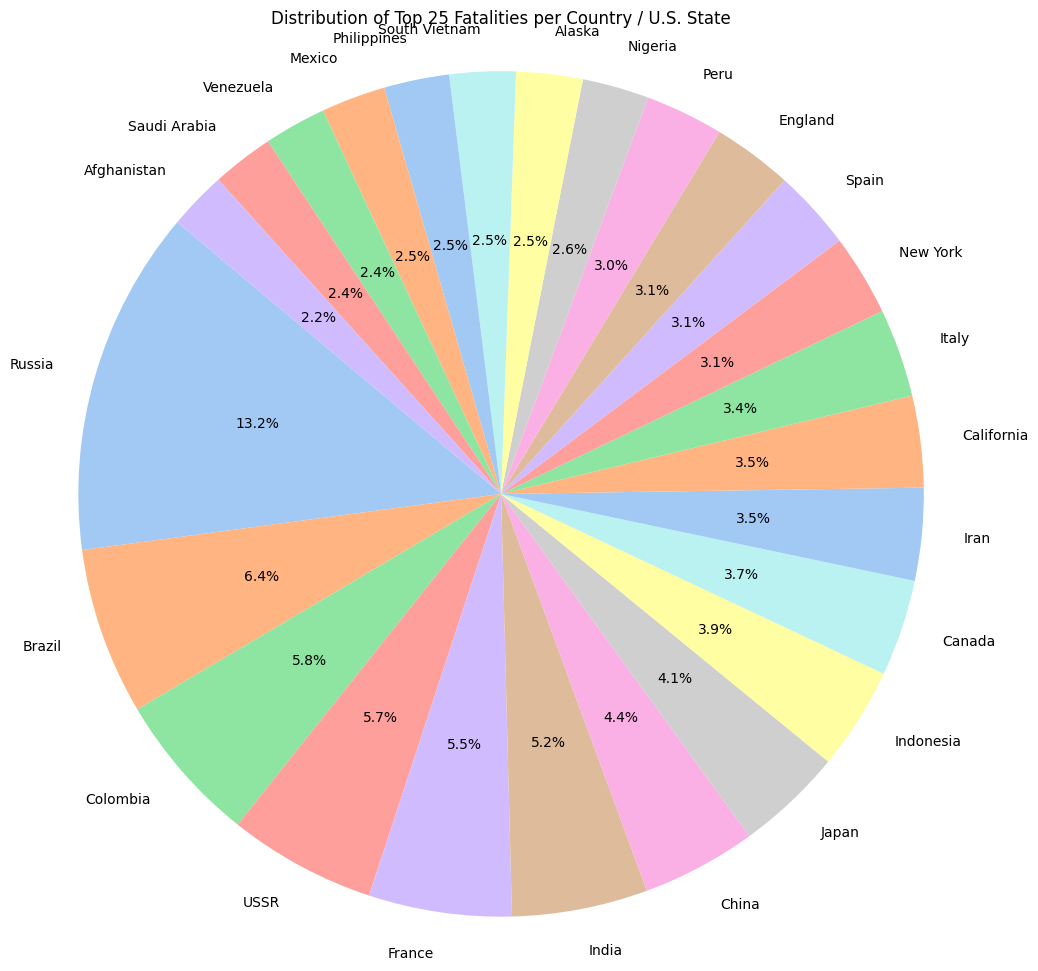

In [10]:
# Question 10

top_25_countries = fatality_locations.groupby('State/Country')['Fatalities'].sum().sort_values(ascending=False).head(25)


plt.figure(figsize=(12, 12))
colors = sns.color_palette('pastel')[0:25]

plt.pie(top_25_countries, labels=top_25_countries.index, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Top 25 Fatalities per Country / U.S. State')
plt.axis('equal')
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


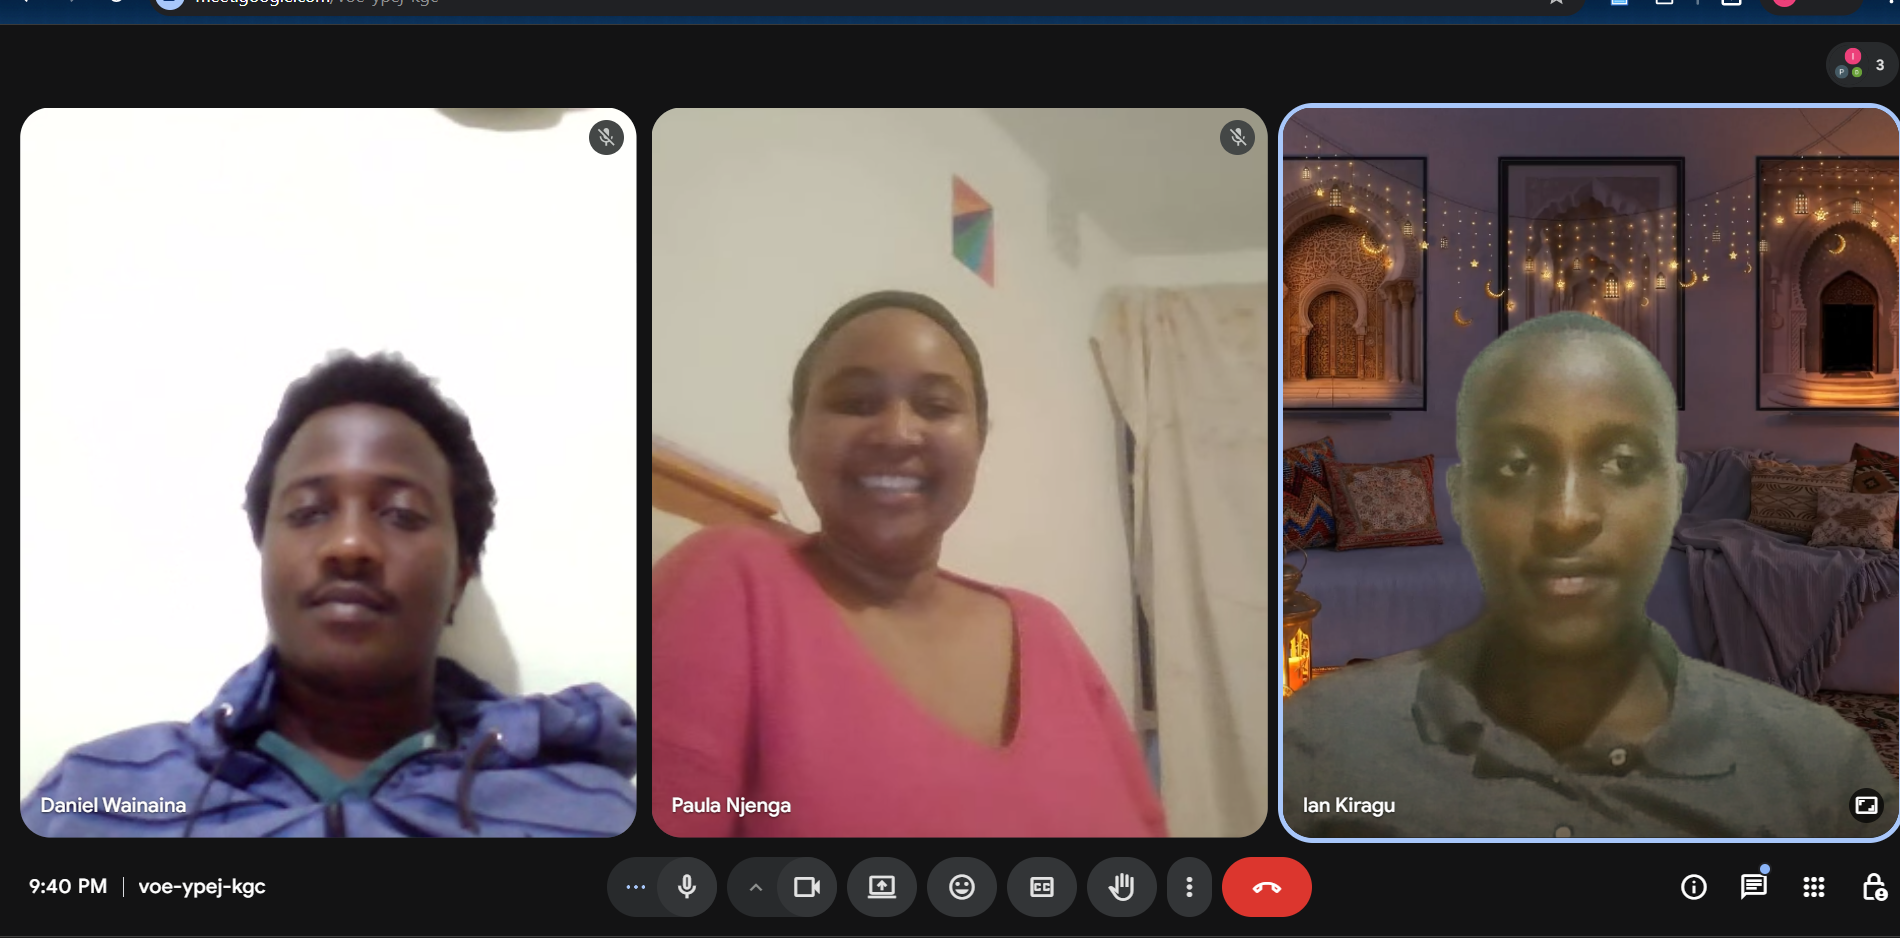

In [12]:
from IPython.display import Image


Image('/content/drive/MyDrive/AI_groupwork/task4photo.png', width=500)